# Proyecto Mundial: Aprendizaje No Supervisado

Este notebook resuelve la Task 2 del proyecto. El objetivo es buscar estructuras ocultas en los pacientes sin usar `condition` para entrenar los algoritmos. La variable `condition` se conserva solamente para interpretar despues si los grupos encontrados tienen alguna relacion con la condicion medica.

## 1. Preparacion del entorno

Importamos librerias, configuramos rutas del proyecto y creamos la carpeta `outputs/task2`. Se usa como entrada principal el dataset limpio generado en Task 1.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    import seaborn as sns
except ModuleNotFoundError:
    print("seaborn no esta instalado en este kernel; instalando con pip...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn==0.13.2"])
    import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def find_project_root(start_path):
    current = Path(start_path).resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "data" / "foot.csv").exists() and (candidate / "notebooks").exists():
            return candidate
        nested = candidate / "mundial_project"
        if (nested / "data" / "foot.csv").exists() and (nested / "notebooks").exists():
            return nested
    raise FileNotFoundError("No se encontro la carpeta mundial_project desde el directorio actual.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "foot_clean.csv"
if not DATA_PATH.exists():
    DATA_PATH = PROJECT_ROOT / "data" / "foot.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "task2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if sns is not None:
    sns.set_theme(style="whitegrid")
else:
    plt.style.use("default")


def scatterplot(data, x, y, hue, ax, palette=None):
    if sns is not None:
        sns.scatterplot(data=data, x=x, y=y, hue=hue, palette=palette, ax=ax)
        return
    values = sorted(data[hue].dropna().unique())
    cmap_name = "tab10" if palette in (None, "tab10", "Set1", "Set2") else "tab10"
    colors = plt.get_cmap(cmap_name)(np.linspace(0, 1, max(len(values), 2)))
    for color, value in zip(colors, values):
        mask = data[hue] == value
        ax.scatter(data.loc[mask, x], data.loc[mask, y], s=38, alpha=0.75, label=f"{hue}={value}", color=color)
    ax.legend()

DATA_PATH

WindowsPath('E:/University/4to/ML/mundial_project/data/processed/foot_clean.csv')

## 2. Carga y preparacion de datos

Separamos `X` e `y`. `condition` no entra al preprocesamiento ni a los algoritmos no supervisados; solo se guarda para interpretar los resultados despues.

In [2]:
df = pd.read_csv(DATA_PATH)

target = "condition"
X = df.drop(columns=[target])
y = df[target]

binary_features = ["feature_1", "feature_4", "feature_7"]
categorical_features = ["feature_2", "feature_3", "feature_8", "feature_9", "feature_12"]
continuous_features = ["feature_5", "feature_6", "feature_10", "feature_11", "feature_13"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("bin", "passthrough", binary_features),
    ]
)

X_processed = preprocessor.fit_transform(X)
X_processed = X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed

processed_feature_names = preprocessor.get_feature_names_out()
pd.Series(processed_feature_names, name="feature_procesada").to_csv(
    OUTPUT_DIR / "features_procesadas.csv",
    index=False,
)

print("Dataset original:", df.shape)
print("Matriz procesada sin condition:", X_processed.shape)
print("condition usada solo para interpretacion:", sorted(y.unique()))

Dataset original: (297, 14)
Matriz procesada sin condition: (297, 25)
condition usada solo para interpretacion: [np.int64(0), np.int64(1)]


## 3. PCA

PCA reduce la dimensionalidad para visualizar estructura global. El ajuste se realiza solo con `X_processed`; `condition` se usa despues para colorear e interpretar.

In [3]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_processed)

pca_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "condition": y})
pca_df.to_csv(OUTPUT_DIR / "pca_scores.csv", index=False)

pca_full = PCA()
pca_full.fit(X_processed)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
pca_varianza = pd.DataFrame(
    {
        "componente": [f"PC{i}" for i in range(1, len(cum_var) + 1)],
        "varianza_explicada": pca_full.explained_variance_ratio_,
        "varianza_acumulada": cum_var,
    }
)
pca_varianza.to_csv(OUTPUT_DIR / "pca_varianza.csv", index=False)

componentes_80 = int(np.argmax(cum_var >= 0.80) + 1)
componentes_90 = int(np.argmax(cum_var >= 0.90) + 1)

print("Varianza PC1 y PC2:", pca_2d.explained_variance_ratio_)
print("Varianza acumulada PC1+PC2:", pca_2d.explained_variance_ratio_.sum())
print("Componentes para 80%:", componentes_80)
print("Componentes para 90%:", componentes_90)
pca_varianza.head(10)

Varianza PC1 y PC2: [0.25592487 0.14340042]
Varianza acumulada PC1+PC2: 0.3993252970351424
Componentes para 80%: 8
Componentes para 90%: 12


,componente,varianza_explicada,varianza_acumulada
0,PC1,0.255925,0.255925
1,PC2,0.143400,0.399325
2,PC3,0.107320,0.506645
3,PC4,0.097286,0.603931
4,PC5,0.061853,0.665784
5,PC6,0.055114,0.720897
6,PC7,0.054360,0.775258
7,PC8,0.037222,0.812479
8,PC9,0.033545,0.846024
9,PC10,0.029824,0.875848


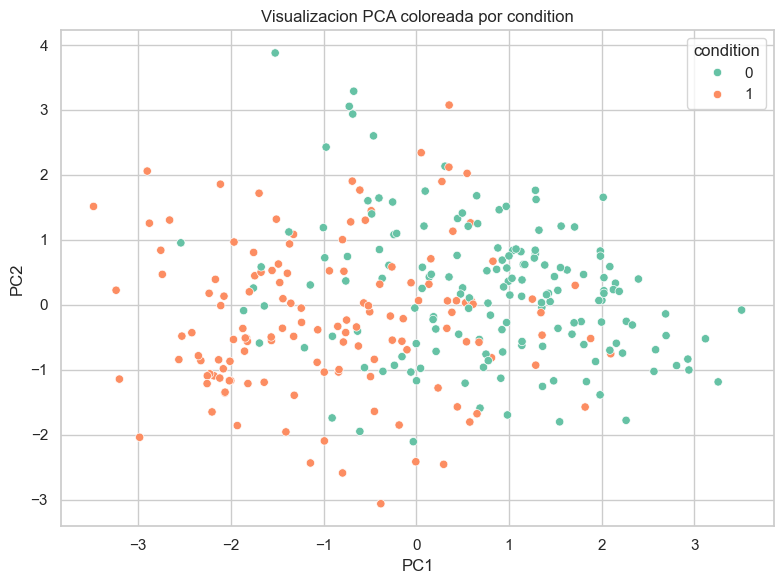

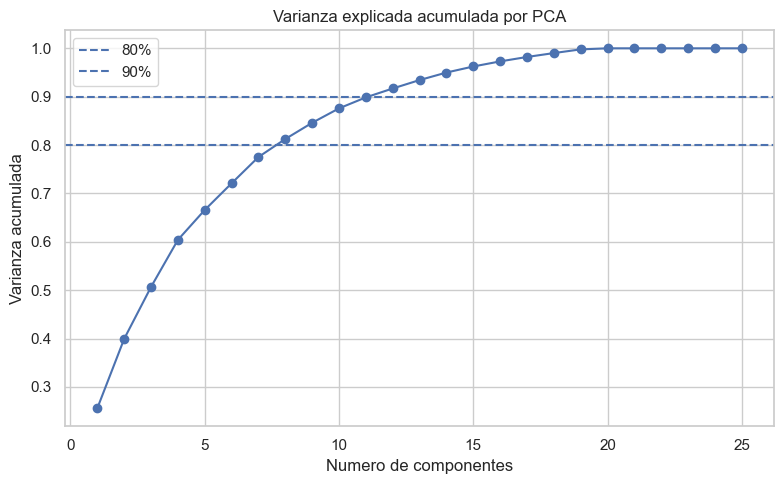

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
scatterplot(data=pca_df, x="PC1", y="PC2", hue="condition", palette="Set2", ax=ax)
ax.set_title("Visualizacion PCA coloreada por condition")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pca_condition.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
ax.axhline(0.80, linestyle="--", label="80%")
ax.axhline(0.90, linestyle="--", label="90%")
ax.set_xlabel("Numero de componentes")
ax.set_ylabel("Varianza acumulada")
ax.set_title("Varianza explicada acumulada por PCA")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pca_varianza_acumulada.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. K-Means

Probamos `k=2` hasta `k=8`. La seleccion se guia por metricas internas: silhouette, Davies-Bouldin, Calinski-Harabasz e inercia.

In [4]:
def clustering_metrics(X_data, labels):
    unique_labels = set(labels)
    if len(unique_labels) < 2 or len(unique_labels) >= len(labels):
        return {"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}
    return {
        "silhouette": silhouette_score(X_data, labels),
        "davies_bouldin": davies_bouldin_score(X_data, labels),
        "calinski_harabasz": calinski_harabasz_score(X_data, labels),
    }


kmeans_results = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_processed)
    kmeans_results.append({"k": k, "inertia": kmeans.inertia_, **clustering_metrics(X_processed, labels)})

kmeans_results_df = pd.DataFrame(kmeans_results)
kmeans_results_df.to_csv(OUTPUT_DIR / "kmeans_metricas.csv", index=False)
best_k = int(kmeans_results_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
kmeans_results_df

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,2049.743943,0.168224,2.074719,65.267690
1,3,1871.517466,0.122250,2.275818,49.619397
2,4,1763.192477,0.107557,2.224447,40.992808
3,5,1684.748472,0.101950,2.411273,35.465269
4,6,1613.737757,0.102455,2.273644,32.080288
5,7,1562.894203,0.095350,2.232103,29.080768
6,8,1508.626683,0.086694,2.128847,27.219074


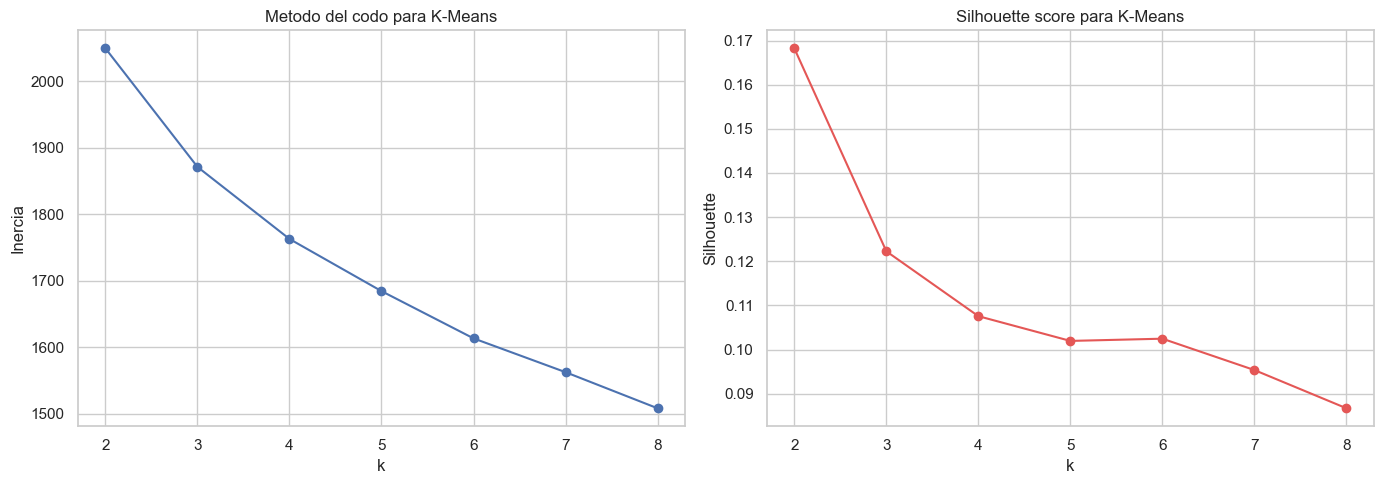

Mejor k por silhouette: 2


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(kmeans_results_df["k"], kmeans_results_df["inertia"], marker="o")
axes[0].set_title("Metodo del codo para K-Means")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")

axes[1].plot(kmeans_results_df["k"], kmeans_results_df["silhouette"], marker="o", color="#E45756")
axes[1].set_title("Silhouette score para K-Means")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "kmeans_metricas.png", dpi=180, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "kmeans_elbow_silhouette.png", dpi=180, bbox_inches="tight")
plt.show()

print("Mejor k por silhouette:", best_k)

## 5. Perfil de clusters K-Means

Entrenamos K-Means con el mejor `k` y analizamos los perfiles con las variables originales. El cruce con `condition` ocurre despues del clustering, solo para interpretacion.

In [5]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(X_processed)

df_clusters = df.copy()
df_clusters["cluster_kmeans"] = cluster_labels
df_clusters.to_csv(OUTPUT_DIR / "kmeans_clusters.csv", index=False)

cluster_profile = df_clusters.groupby("cluster_kmeans").mean(numeric_only=True).T
if cluster_profile.shape[1] == 2:
    cluster_profile["diferencia_cluster_1_menos_0"] = cluster_profile.iloc[:, 1] - cluster_profile.iloc[:, 0]
cluster_profile.to_csv(OUTPUT_DIR / "kmeans_perfil_clusters.csv")

kmeans_crosstab = pd.crosstab(df_clusters["cluster_kmeans"], df_clusters["condition"])
kmeans_crosstab_pct = pd.crosstab(df_clusters["cluster_kmeans"], df_clusters["condition"], normalize="index") * 100
kmeans_crosstab.to_csv(OUTPUT_DIR / "kmeans_condition_crosstab.csv")
kmeans_crosstab_pct.to_csv(OUTPUT_DIR / "kmeans_condition_crosstab_pct.csv")

print("ARI:", adjusted_rand_score(y, cluster_labels))
print("NMI:", normalized_mutual_info_score(y, cluster_labels))
display(cluster_profile)
display(kmeans_crosstab)
display(kmeans_crosstab_pct.round(2))

ARI: 0.24915987198304793
NMI: 0.18893255848421184


cluster_kmeans,0,1,diferencia_cluster_1_menos_0
feature_1,0.121795,0.170213,0.048418
feature_2,1.916667,2.425532,0.508865
feature_3,0.326923,0.907801,0.580878
feature_4,0.141026,0.531915,0.390889
feature_5,49.551282,60.063830,10.512548
feature_6,238.391026,257.262411,18.871386
feature_7,0.660256,0.695035,0.034779
feature_8,0.333333,1.056738,0.723404
feature_9,0.769231,1.248227,0.478996
feature_10,163.852564,133.829787,-30.022777


condition,0,1
cluster_kmeans,,
0,121,35
1,39,102


condition,0,1
cluster_kmeans,,
0,77.56,22.44
1,27.66,72.34


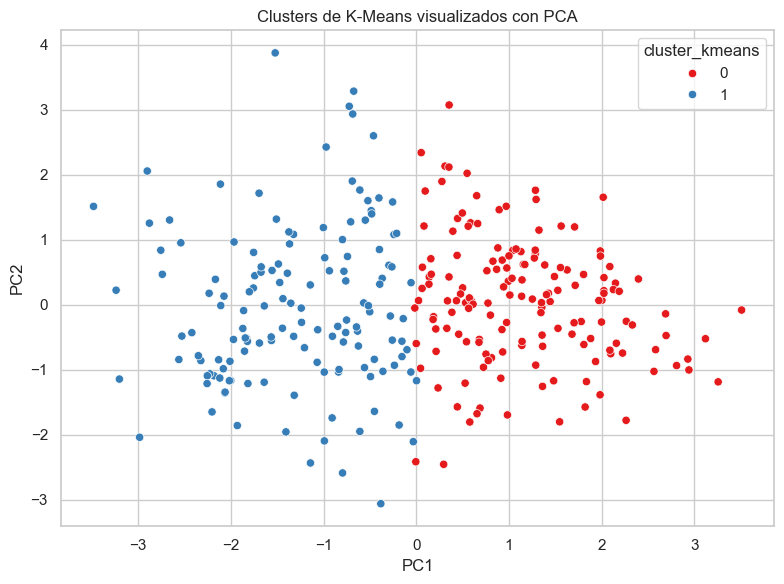

In [16]:
pca_cluster_df = pca_df.copy()
pca_cluster_df["cluster_kmeans"] = cluster_labels

fig, ax = plt.subplots(figsize=(8, 6))
scatterplot(data=pca_cluster_df, x="PC1", y="PC2", hue="cluster_kmeans", palette="Set1", ax=ax)
ax.set_title("Clusters de K-Means visualizados con PCA")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "kmeans_clusters_pca.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Clustering jerarquico

El clustering jerarquico sirve como comparacion frente a K-Means. Se evalua con las mismas metricas internas.

In [6]:
agg_results = []
for k in range(2, 7):
    agg = AgglomerativeClustering(n_clusters=k)
    labels = agg.fit_predict(X_processed)
    agg_results.append({"k": k, **clustering_metrics(X_processed, labels)})

agg_results_df = pd.DataFrame(agg_results)
agg_results_df.to_csv(OUTPUT_DIR / "agglomerative_metricas.csv", index=False)
best_agg_k = int(agg_results_df.sort_values("silhouette", ascending=False).iloc[0]["k"])

agg_final = AgglomerativeClustering(n_clusters=best_agg_k)
agg_labels = agg_final.fit_predict(X_processed)
df_clusters["cluster_agglomerative"] = agg_labels
df_clusters[["cluster_agglomerative", "condition"]].to_csv(OUTPUT_DIR / "agglomerative_clusters.csv", index=False)

agg_crosstab = pd.crosstab(df_clusters["cluster_agglomerative"], df_clusters["condition"])
agg_crosstab.to_csv(OUTPUT_DIR / "agglomerative_condition_crosstab.csv")

display(agg_results_df)
display(agg_crosstab)
print("Mejor k jerarquico:", best_agg_k)

,k,silhouette,davies_bouldin,calinski_harabasz
0,2,0.156155,2.075717,47.126174
1,3,0.107879,2.719312,37.995394
2,4,0.079701,2.495985,32.364431
3,5,0.082653,2.472180,28.407183
4,6,0.080289,2.319469,25.777701


condition,0,1
cluster_agglomerative,,
0,153,71
1,7,66


Mejor k jerarquico: 2


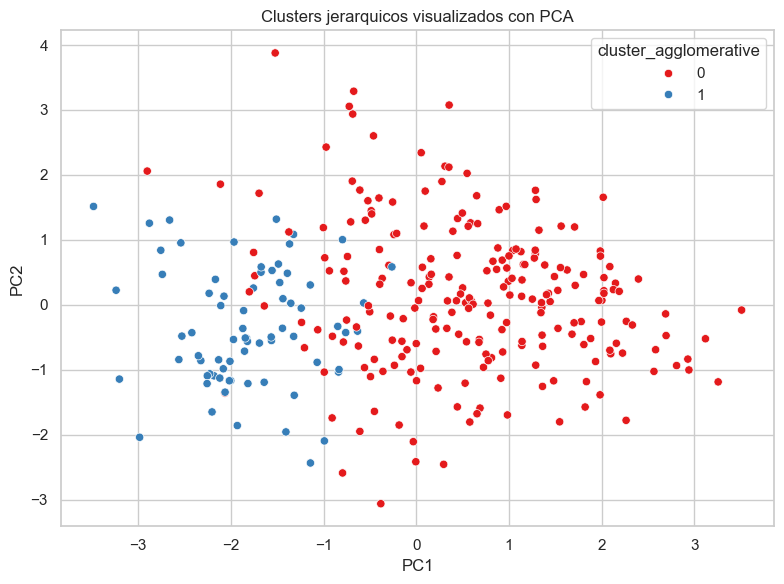

In [7]:
pca_agg_df = pca_df.copy()
pca_agg_df["cluster_agglomerative"] = agg_labels

fig, ax = plt.subplots(figsize=(8, 6))
scatterplot(data=pca_agg_df, x="PC1", y="PC2", hue="cluster_agglomerative", palette="Set1", ax=ax)
ax.set_title("Clusters jerarquicos visualizados con PCA")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "agglomerative_clusters_pca.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. DBSCAN

DBSCAN busca regiones densas y marca puntos de ruido. Si muchos puntos quedan como ruido o hay demasiados grupos pequenos, eso tambien es un resultado util para documentar.

In [8]:
dbscan_results = []
best_dbscan_labels = None
best_dbscan_silhouette = -np.inf

for eps in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    for min_samples in [3, 5, 10]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_processed)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        metrics = clustering_metrics(X_processed, labels) if n_clusters > 1 else {"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}
        dbscan_results.append({"eps": eps, "min_samples": min_samples, "n_clusters": n_clusters, "n_noise": n_noise, **metrics})
        if metrics["silhouette"] is not None and metrics["silhouette"] > best_dbscan_silhouette:
            best_dbscan_silhouette = metrics["silhouette"]
            best_dbscan_labels = labels

dbscan_results_df = pd.DataFrame(dbscan_results)
dbscan_results_df.to_csv(OUTPUT_DIR / "dbscan_metricas.csv", index=False)
display(dbscan_results_df)

if best_dbscan_labels is None:
    best_dbscan_labels = DBSCAN(eps=3.0, min_samples=3).fit_predict(X_processed)

,eps,min_samples,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz
0,0.5,3,0,297,NaN,NaN,NaN
1,0.5,5,0,297,NaN,NaN,NaN
2,0.5,10,0,297,NaN,NaN,NaN
3,1.0,3,1,294,NaN,NaN,NaN
4,1.0,5,0,297,NaN,NaN,NaN
5,1.0,10,0,297,NaN,NaN,NaN
6,1.5,3,7,251,-0.186992,1.777472,4.271191
7,1.5,5,1,277,NaN,NaN,NaN
8,1.5,10,0,297,NaN,NaN,NaN
9,2.0,3,9,136,-0.099911,2.179214,5.978069


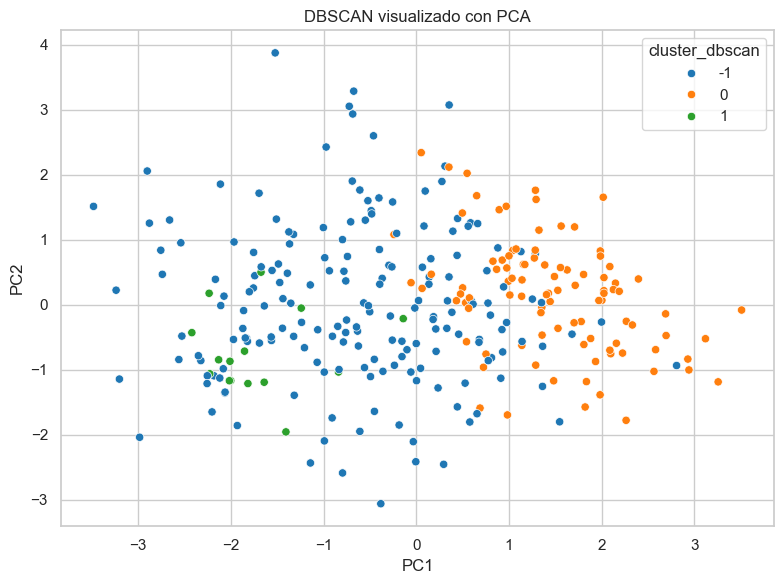

In [20]:
pca_dbscan_df = pca_df.copy()
pca_dbscan_df["cluster_dbscan"] = best_dbscan_labels

fig, ax = plt.subplots(figsize=(8, 6))
scatterplot(data=pca_dbscan_df, x="PC1", y="PC2", hue="cluster_dbscan", palette="tab10", ax=ax)
ax.set_title("DBSCAN visualizado con PCA")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dbscan_clusters_pca.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. t-SNE

t-SNE se usa como visualizacion no lineal exploratoria. Sus resultados se interpretan visualmente, no como prueba definitiva de separacion.

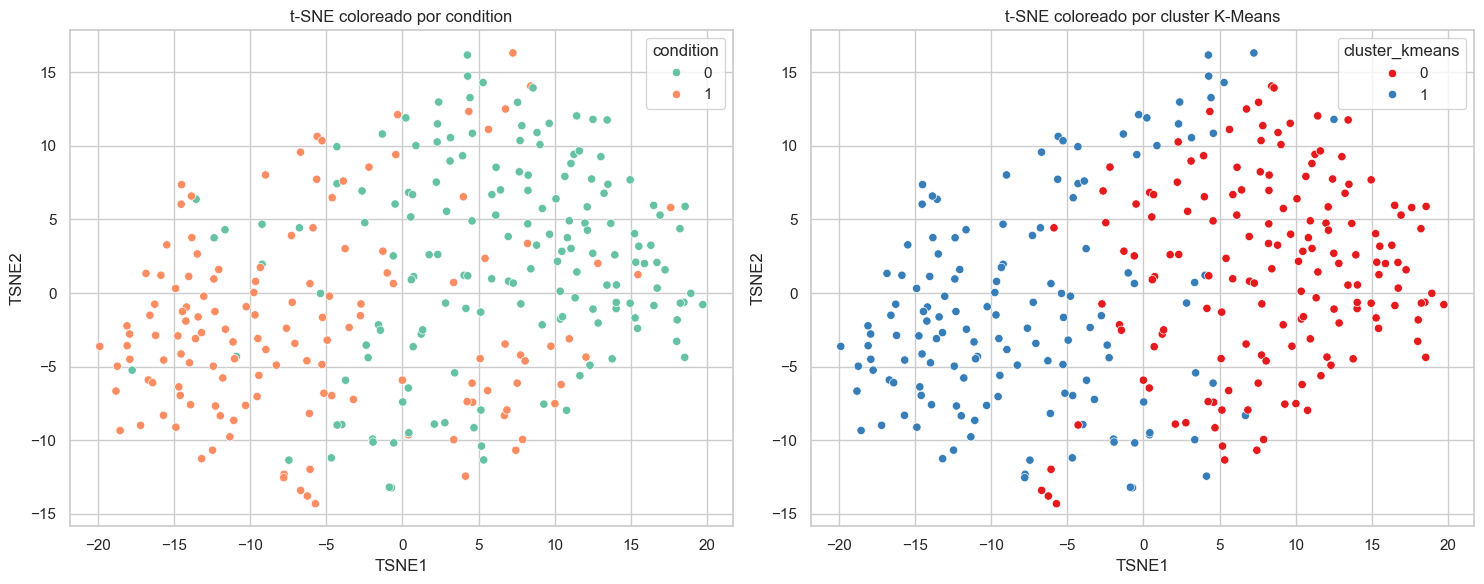

In [9]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)
X_tsne = tsne.fit_transform(X_processed)

tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "condition": y,
    "cluster_kmeans": cluster_labels,
})
tsne_df.to_csv(OUTPUT_DIR / "tsne_scores.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="condition", palette="Set2", ax=axes[0])
axes[0].set_title("t-SNE coloreado por condition")
scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="cluster_kmeans", palette="Set1", ax=axes[1])
axes[1].set_title("t-SNE coloreado por cluster K-Means")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "tsne_condition_kmeans.png", dpi=180, bbox_inches="tight")
plt.show()

## 9. Conclusiones

Los experimentos permiten evaluar si las features medicas anonimizadas contienen una estructura latente. K-Means y clustering jerarquico comparan posibles particiones globales; DBSCAN evalua si hay grupos densos y ruido; PCA y t-SNE ayudan a visualizar la estructura. Si los clusters se cruzan de forma clara con `condition`, la interpretacion correcta es que los grupos estan asociados con la variable objetivo, no que la predicen ni que sean diagnosticos.